In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)
%pip install xgboost
import joblib

try:
    from xgboost import XGBClassifier
    XGBOOST = True
    print('✅ XGBoost available')
except ImportError:
    XGBOOST = False
    print('  XGBoost not found — will skip it')

sns.set_theme(style='whitegrid', palette='muted')
print(' All libraries loaded')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.3 MB/s  0:00:00m0:00:01
Note: you may need to restart the kernel to use updated packages.
✅ XGBoost available
 All libraries loaded


In [2]:
df= pd.read_csv("credit_risk_dataset.csv")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
## EDA
print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])

print('\n=== Target Distribution (loan_status) ===')
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print('\n=== Descriptive Statistics ===')
df.describe()

=== Shape ===
(32581, 12)

=== Data Types ===
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

=== Missing Values ===
person_emp_length     895
loan_int_rate        3116
dtype: int64

=== Target Distribution (loan_status) ===
loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    78.18%
1    21.82%
Name: proportion, dtype: str

=== Descriptive Statistics ===


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [15]:
df.shape

(32581, 12)

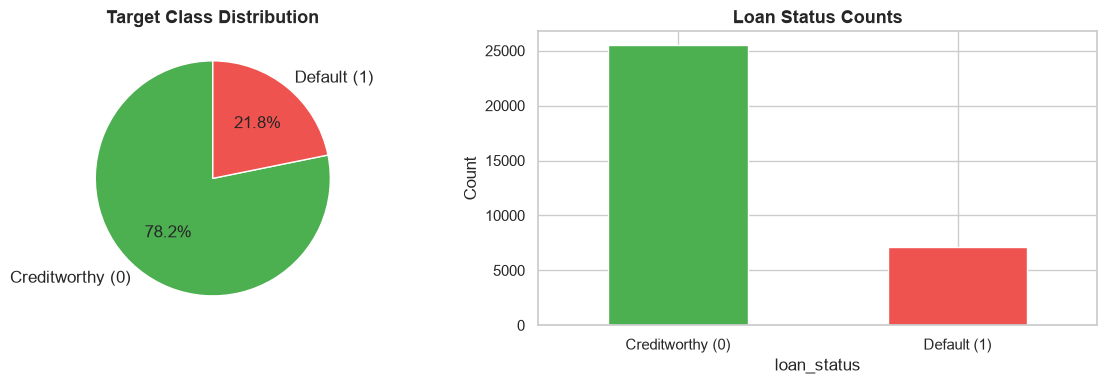

In [16]:
# Target class distribution pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['loan_status'].value_counts()
axes[0].pie(counts, labels=['Creditworthy (0)', 'Default (1)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#EF5350'],
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Target Class Distribution', fontweight='bold', fontsize=13)

counts.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#EF5350'], edgecolor='white')
axes[1].set_xticklabels(['Creditworthy (0)', 'Default (1)'], rotation=0)
axes[1].set_title('Loan Status Counts', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

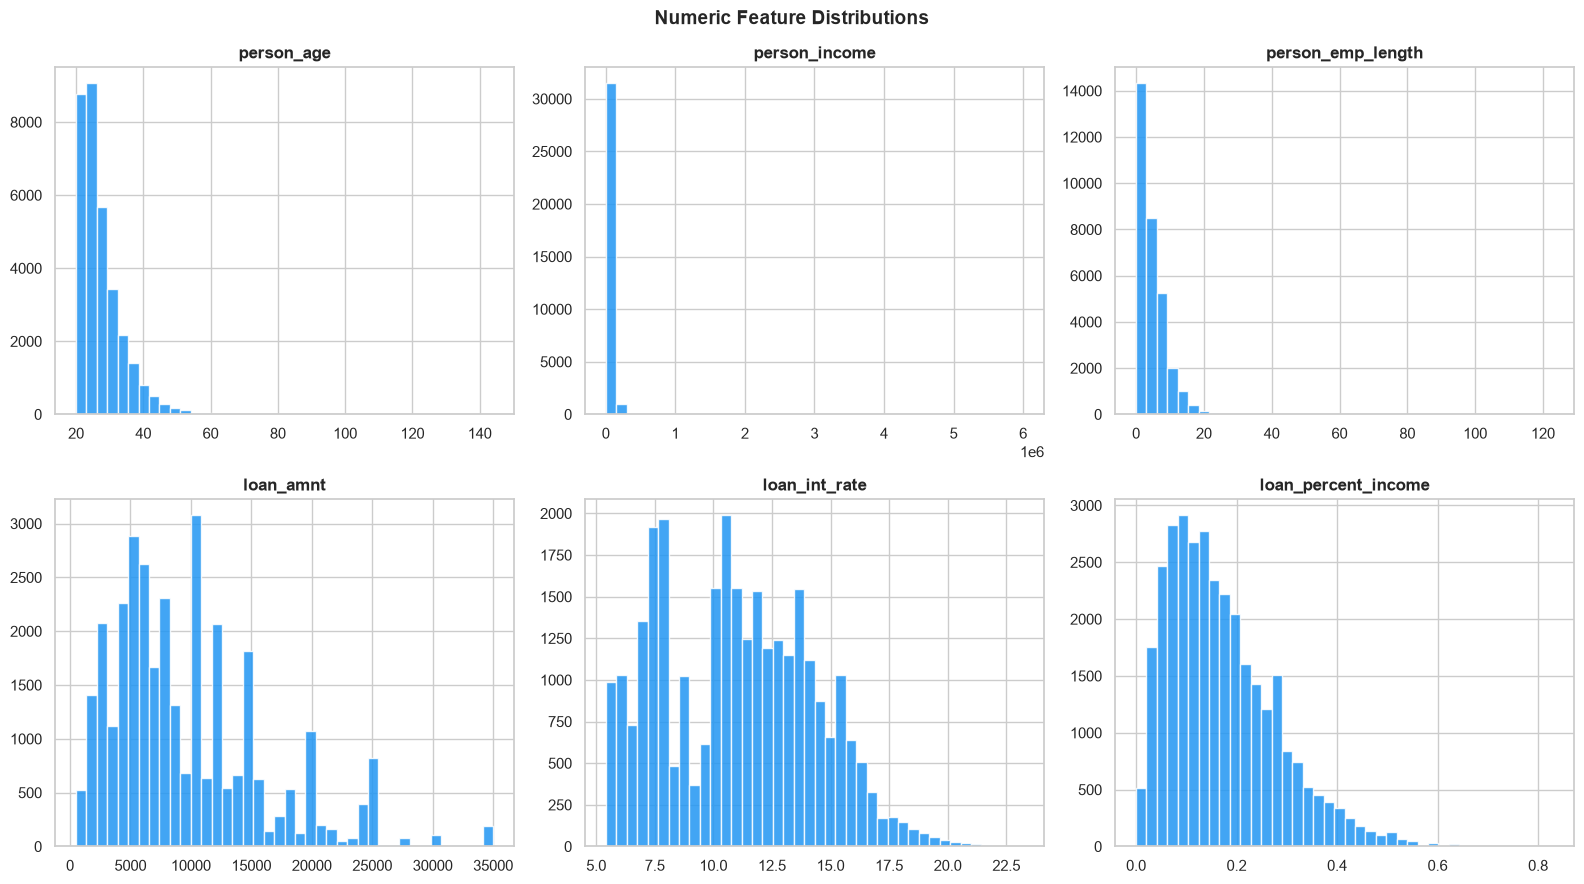

In [17]:
# Numeric feature distributions
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(bins=40, ax=ax, color='#2196F3', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

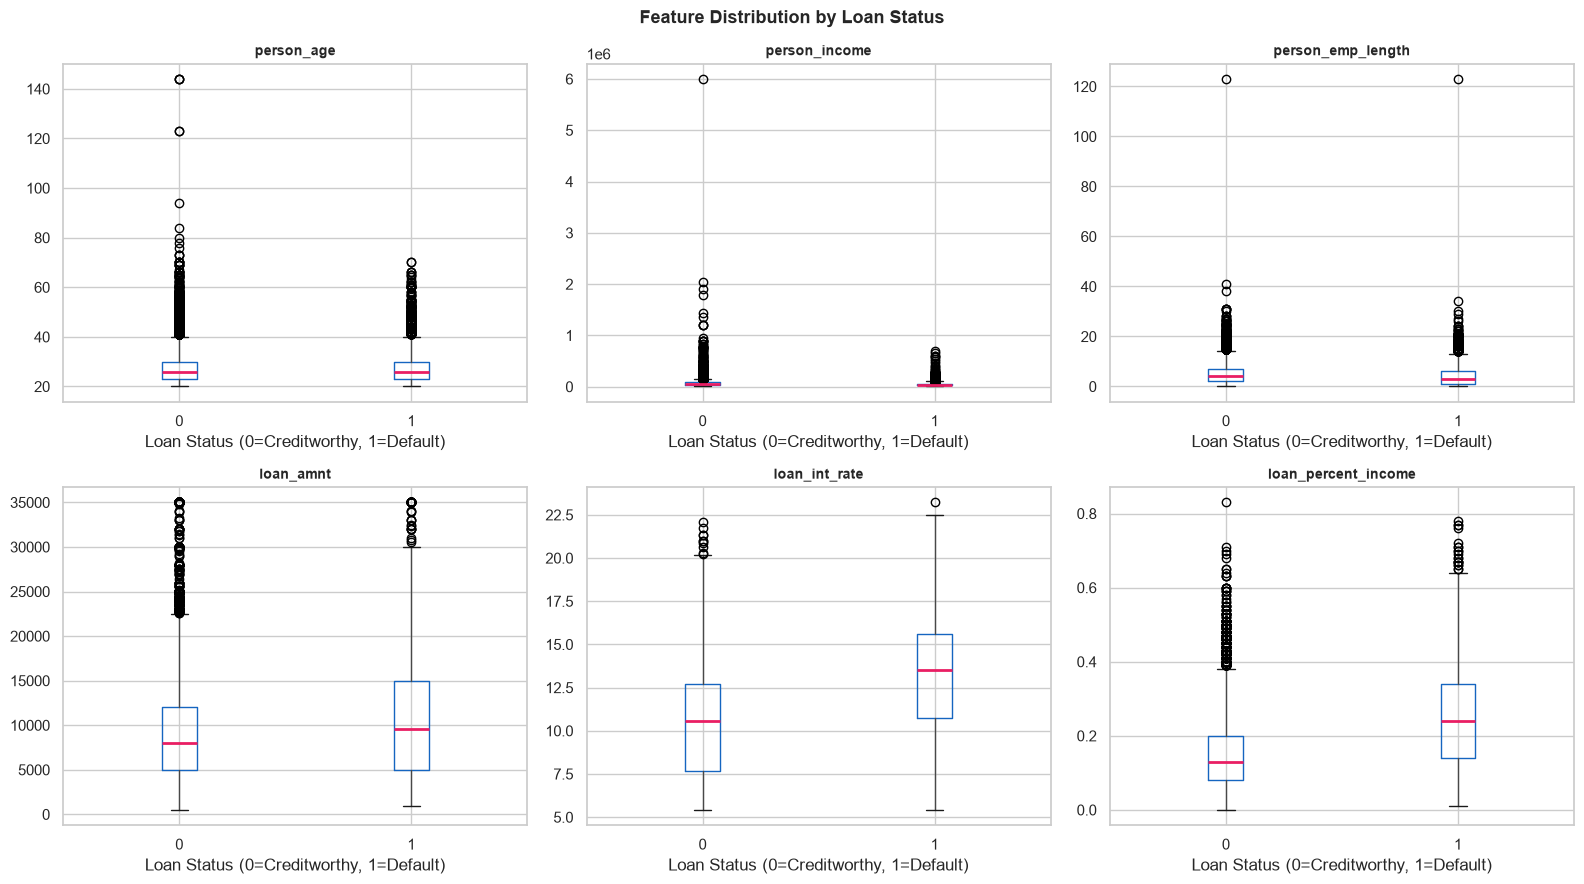

In [18]:
# Boxplots: numeric features vs target
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    df.boxplot(column=col, by='loan_status', ax=ax,
               boxprops=dict(color='#1565C0'),
               medianprops=dict(color='#E91E63', linewidth=2))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Loan Status (0=Creditworthy, 1=Default)')
plt.suptitle('Feature Distribution by Loan Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


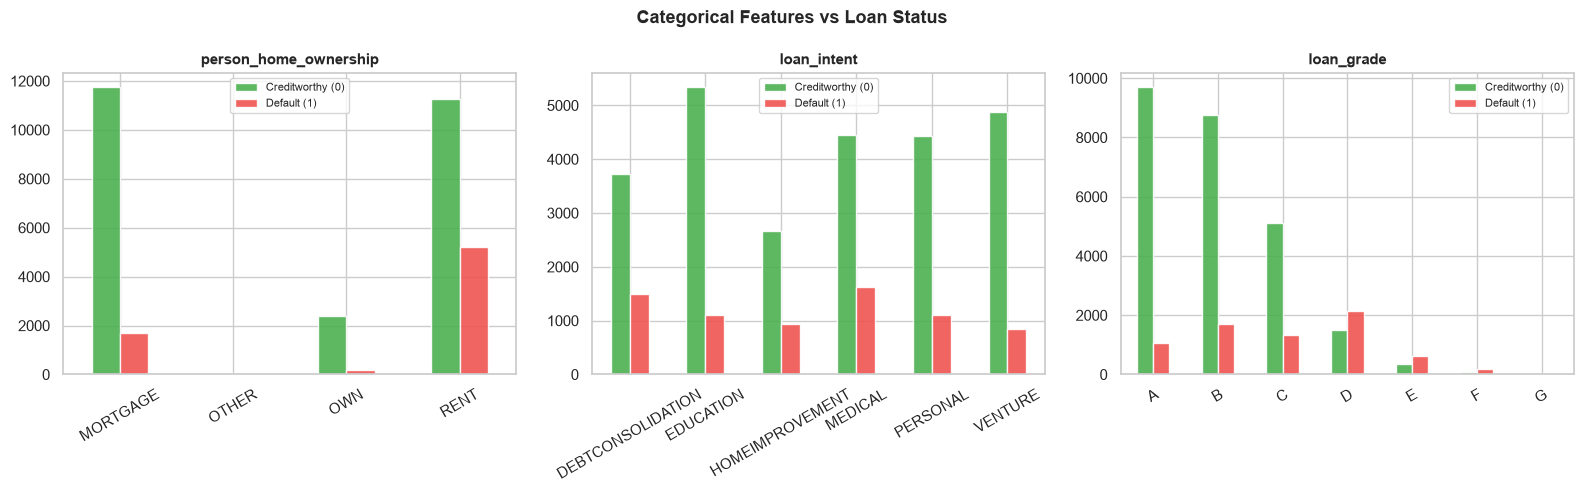

In [19]:
# Categorical features vs target
cat_plot_cols = ['person_home_ownership', 'loan_intent', 'loan_grade']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_plot_cols):
    ct = df.groupby([col, 'loan_status']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['#4CAF50', '#EF5350'], edgecolor='white', alpha=0.9)
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(['Creditworthy (0)', 'Default (1)'], fontsize=8)

plt.suptitle('Categorical Features vs Loan Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

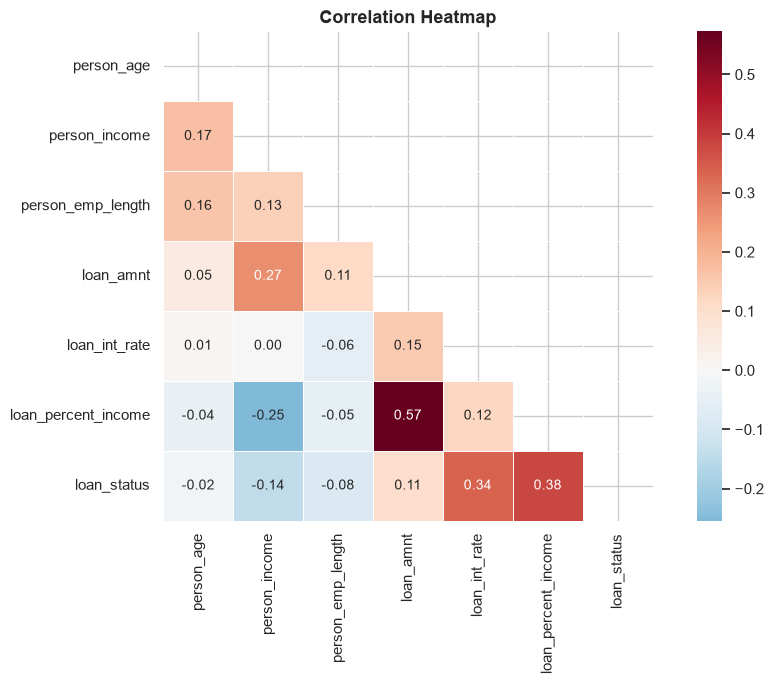

In [20]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[num_cols + ['loan_status']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, square=True, annot_kws={'size': 10})
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
print(f'Missing values BEFORE: {df.isnull().sum().sum()}')

# Numeric columns → fill with median
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'   Filled [{col}] with median = {median_val:.2f}')

# Categorical columns → fill with mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'   Filled [{col}] with mode = "{mode_val}"')

print(f'\nMissing values AFTER: {df.isnull().sum().sum()}')

Missing values BEFORE: 4011
   Filled [person_emp_length] with median = 4.00
   Filled [loan_int_rate] with median = 10.99

Missing values AFTER: 0


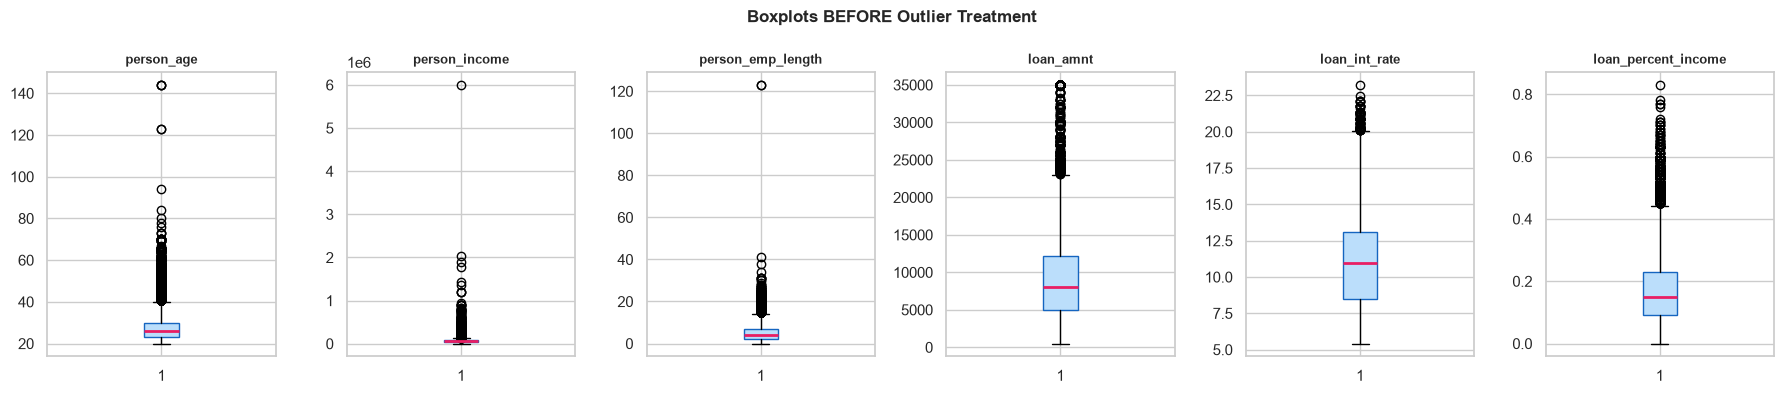

In [22]:
##Outlier detection & Treatment (IQR)
# Visualise outliers before treatment
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
               medianprops=dict(color='#E91E63', linewidth=2))
    ax.set_title(col, fontsize=9, fontweight='bold')
plt.suptitle('Boxplots BEFORE Outlier Treatment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# IQR capping
outlier_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = df[col].copy()
    df[col] = df[col].clip(lower, upper)
    n_changed = (before != df[col]).sum()
    if n_changed > 0:
        print(f'   {col}: capped {n_changed} outliers → [{lower:.2f}, {upper:.2f}]')

print('\nOutlier treatment complete!')

   person_age: capped 1494 outliers → [12.50, 40.50]
   person_income: capped 1484 outliers → [-22550.00, 140250.00]
   person_emp_length: capped 853 outliers → [-5.50, 14.50]
   loan_amnt: capped 1689 outliers → [-5800.00, 23000.00]
   loan_int_rate: capped 70 outliers → [1.56, 20.04]
   loan_percent_income: capped 651 outliers → [-0.12, 0.44]

Outlier treatment complete!


In [24]:
##Feature engineeting 
# New derived features
df['loan_to_income']      = df['loan_amnt'] / (df['person_income'] + 1)
df['high_interest_flag']  = (df['loan_int_rate'] > df['loan_int_rate'].quantile(0.75)).astype(int)
df['low_income_flag']     = (df['person_income'] < df['person_income'].quantile(0.25)).astype(int)
df['high_loan_pct_flag']  = (df['loan_percent_income'] > 0.4).astype(int)

df['emp_exp_bucket'] = pd.cut(
    df['person_emp_length'],
    bins=[-1, 2, 5, 10, 100],
    labels=['junior', 'mid', 'senior', 'veteran']
).astype(str)

df['income_bracket'] = pd.cut(
    df['person_income'],
    bins=[0, 30000, 60000, 100000, 1e9],
    labels=['low', 'medium', 'high', 'very_high']
).astype(str)

print(f' Features after engineering: {df.shape[1]} columns')
df[['loan_to_income','high_interest_flag','low_income_flag',
    'high_loan_pct_flag','emp_exp_bucket','income_bracket']].head()

 Features after engineering: 18 columns


,loan_to_income,high_interest_flag,low_income_flag,high_loan_pct_flag,emp_exp_bucket,income_bracket
0,0.389824,1,0,1,veteran,medium
1,0.104156,0,1,0,mid,low
2,0.572857,0,1,1,junior,low
3,0.351140,1,0,1,mid,high
4,0.422786,1,0,1,senior,medium


In [25]:
##Encoding (One-Hot & Label)
TARGET = 'loan_status'

cat_cols = [c for c in df.select_dtypes('object').columns if c != TARGET]
ohe_cols = [c for c in cat_cols if df[c].nunique() <= 10]
print(f'One-Hot Encoding: {ohe_cols}')

df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

# Fix: newer pandas returns bool dtype — cast to int
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df.columns = df.columns.astype(str)

print(f' Shape after encoding: {df.shape}')
print(f' No NaN: {df.isnull().sum().sum() == 0}')
df.head(3)

One-Hot Encoding: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'emp_exp_bucket', 'income_bracket']
 Shape after encoding: (32581, 33)
 No NaN: True


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_to_income,high_interest_flag,...,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,emp_exp_bucket_mid,emp_exp_bucket_senior,emp_exp_bucket_veteran,income_bracket_low,income_bracket_medium,income_bracket_very_high
0,22.0,59000,14.5,23000,16.02,1,0.44,3,0.389824,1,...,0,0,0,1,0,0,1,0,1,0
1,21.0,9600,5.0,1000,11.14,0,0.10,2,0.104156,0,...,0,0,0,0,1,0,0,1,0,0
2,25.0,9600,1.0,5500,12.87,1,0.44,3,0.572857,0,...,0,0,0,0,0,0,0,1,0,0


In [26]:
##Train & split data
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f' Train set : {X_train.shape}  |  Target balance: {dict(y_train.value_counts())}')
print(f' Test set  : {X_test.shape}   |  Target balance: {dict(y_test.value_counts())}')

 Train set : (26064, 32)  |  Target balance: {0: np.int64(20378), 1: np.int64(5686)}
 Test set  : (6517, 32)   |  Target balance: {0: np.int64(5095), 1: np.int64(1422)}


In [27]:
## Feature Scaling
num_scale_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s  = X_test.copy()

X_train_s[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])
X_test_s[num_scale_cols]  = scaler.transform(X_test[num_scale_cols])

print(f' Scaled {len(num_scale_cols)} numeric columns')
print(f' NaN check — Train: {X_train_s.isnull().sum().sum()} | Test: {X_test_s.isnull().sum().sum()}')

 Scaled 32 numeric columns
 NaN check — Train: 0 | Test: 0


In [28]:
##Model Training with Grid Search CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['lbfgs', 'liblinear'],
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy'],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'max_features': ['sqrt', 'log2'],
        }
    },
}

if XGBOOST:
    model_configs['XGBoost'] = {
        'model': XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.05, 0.1, 0.2],
            'subsample': [0.8, 1.0],
        }
    }

results = []

for name, config in model_configs.items():
    print(f'\n{"="*55}\n  Training: {name}\n{"="*55}')
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=cv, scoring='roc_auc',
        n_jobs=-1, verbose=0, refit=True
    )
    grid.fit(X_train_s, y_train)
    print(f'  Best Params : {grid.best_params_}')
    print(f'  CV ROC-AUC  : {grid.best_score_:.4f}')
    results.append({
        'name': name,
        'estimator': grid.best_estimator_,
        'cv_auc': grid.best_score_,
        'best_params': grid.best_params_,
    })

results.sort(key=lambda r: r['cv_auc'], reverse=True)

print(f'\n{"─"*55}')
print('   CV Leaderboard (by ROC-AUC)')
print(f'{"─"*55}')
for r in results:
    print(f'  {r["name"]:<22} AUC: {r["cv_auc"]:.4f}')



  Training: Logistic Regression
  Best Params : {'C': 0.1, 'solver': 'lbfgs'}
  CV ROC-AUC  : 0.8745

  Training: Decision Tree
  Best Params : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}
  CV ROC-AUC  : 0.9058

  Training: Random Forest
  Best Params : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
  CV ROC-AUC  : 0.9317

───────────────────────────────────────────────────────
   CV Leaderboard (by ROC-AUC)
───────────────────────────────────────────────────────
  Random Forest          AUC: 0.9317
  Decision Tree          AUC: 0.9058
  Logistic Regression    AUC: 0.8745


In [29]:
##Model Evaluation
feature_names = list(X_test_s.columns)
summary_rows  = []

for r in results:
    name  = r['name']
    model = r['estimator']

    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1] \
             if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    print(f'\n{"="*52}\n  {name}\n{"─"*52}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    if auc: print(f'  ROC-AUC   : {auc:.4f}')
    print()
    print(classification_report(y_test, y_pred,
          target_names=['Creditworthy (0)', 'Default (1)']))

    summary_rows.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4) if auc else None,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('ROC-AUC', ascending=False)
print('\n  Final Leaderboard:')
summary_df


  Random Forest
────────────────────────────────────────────────────
  Accuracy  : 0.9297
  Precision : 0.9471
  Recall    : 0.7180
  F1 Score  : 0.8168
  ROC-AUC   : 0.9331

                  precision    recall  f1-score   support

Creditworthy (0)       0.93      0.99      0.96      5095
     Default (1)       0.95      0.72      0.82      1422

        accuracy                           0.93      6517
       macro avg       0.94      0.85      0.89      6517
    weighted avg       0.93      0.93      0.93      6517


  Decision Tree
────────────────────────────────────────────────────
  Accuracy  : 0.9262
  Precision : 0.9590
  Recall    : 0.6913
  F1 Score  : 0.8034
  ROC-AUC   : 0.9075

                  precision    recall  f1-score   support

Creditworthy (0)       0.92      0.99      0.95      5095
     Default (1)       0.96      0.69      0.80      1422

        accuracy                           0.93      6517
       macro avg       0.94      0.84      0.88      6517
    w

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9297,0.9471,0.7180,0.8168,0.9331
1,Decision Tree,0.9262,0.9590,0.6913,0.8034,0.9075
2,Logistic Regression,0.8680,0.7636,0.5724,0.6543,0.8742


In [40]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_s, y_train)

print("XGBoost trained!")

XGBoost trained!


In [46]:
results.append({
    'name': 'XGBoost',
    'estimator': xgb_model
})
for r in results:
    print(r['name'])
results = [r for r in results if r['name'] != 'XGBoost']   
results.append({
    'name': 'XGBoost',
    'estimator': xgb_model
})

Random Forest
Decision Tree
Logistic Regression
XGBoost


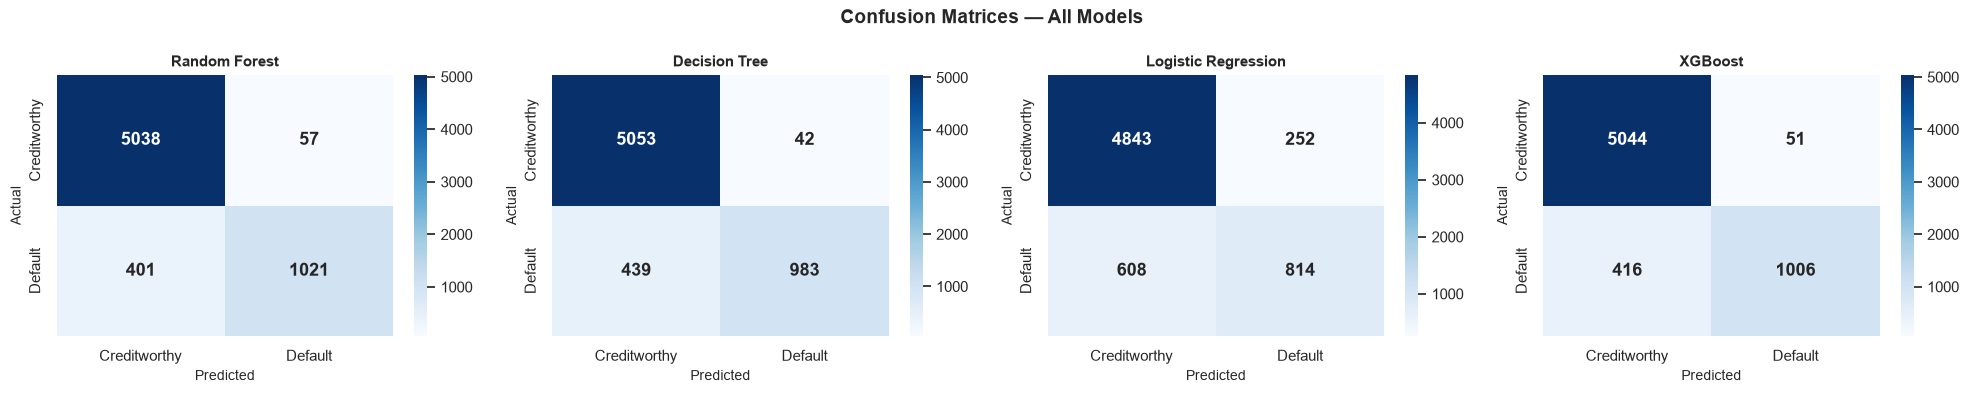

In [47]:
n = len(results)

fig, axes = plt.subplots(
    1, n,
    figsize=(5 * n, 4)
)

if n == 1:
    axes = [axes]

for ax, r in zip(axes, results):

    y_pred = r['estimator'].predict(X_test_s)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Creditworthy', 'Default'],
        yticklabels=['Creditworthy', 'Default'],
        ax=ax,
        annot_kws={'size': 13, 'weight': 'bold'}
    )

    ax.set_title(
        r['name'],
        fontweight='bold',
        fontsize=11
    )

    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle(
    'Confusion Matrices — All Models',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'confusion_matrices.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

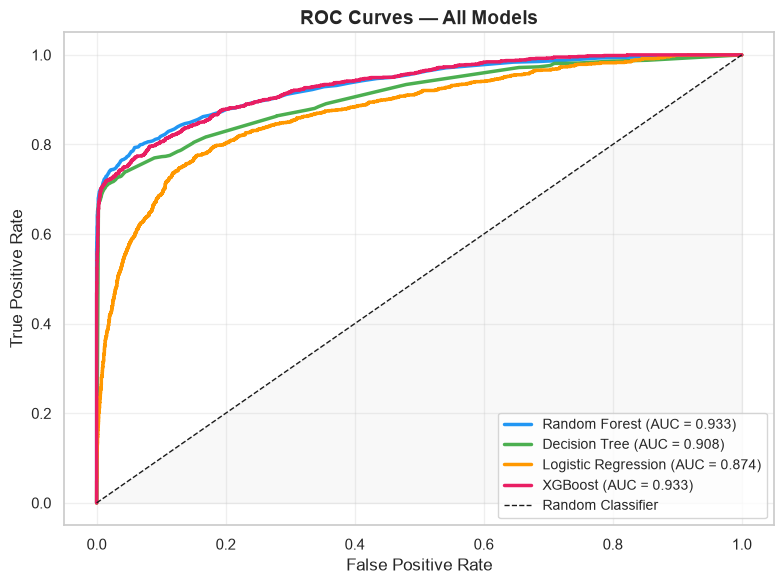

Saved: roc_curves.png


In [48]:
##ROC Curves
plt.figure(figsize=(8, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for r, color in zip(results, colors):

    if hasattr(r['estimator'], 'predict_proba'):

        y_prob = r['estimator'].predict_proba(X_test_s)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_prob)

        auc_val = roc_auc_score(y_test, y_prob)

        plt.plot(
            fpr,
            tpr,
            color=color,
            lw=2.5,
            label=f"{r['name']} (AUC = {auc_val:.3f})"
        )

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    lw=1,
    label='Random Classifier'
)

plt.fill_between(
    [0, 1],
    [0, 1],
    alpha=0.05,
    color='gray'
)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)

plt.title(
    'ROC Curves — All Models',
    fontsize=14,
    fontweight='bold'
)

plt.legend(
    loc='lower right',
    fontsize=10
)

plt.grid(alpha=0.3)
plt.tight_layout()

# Save locally
plt.savefig(
    'roc_curves.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Saved: roc_curves.png')

Best Model: Random Forest | CV AUC: 0.9317


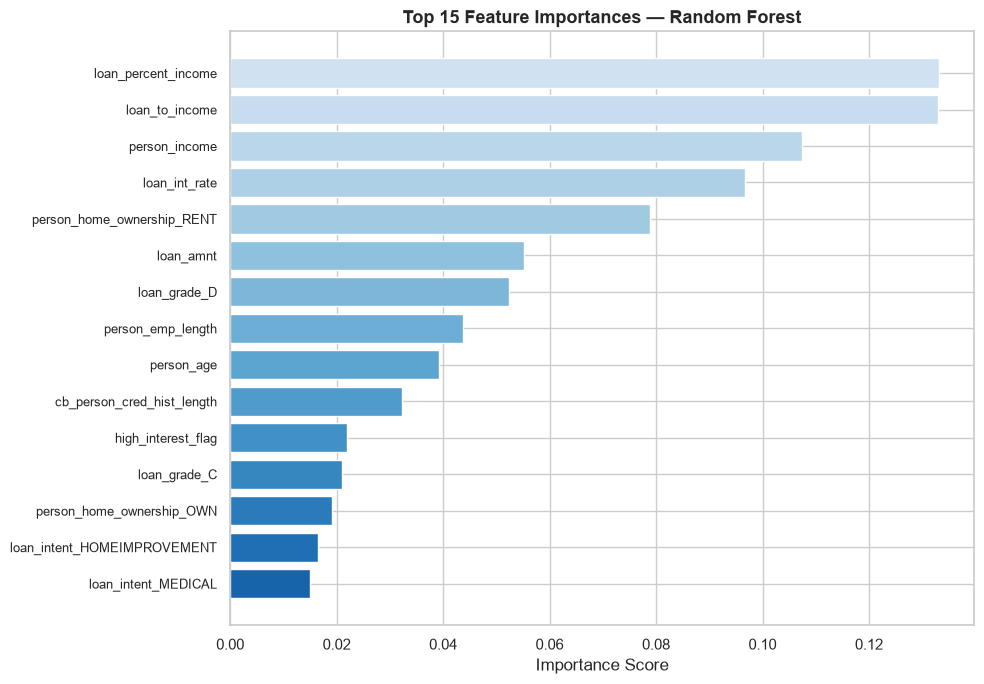

Saved: feature_importance.png


In [51]:
# ============================================
# Feature Importance — Best CV Model
# ============================================

# Only use models that have CV AUC
valid_results = [
    r for r in results
    if 'cv_auc' in r
]

# Find model with highest CV AUC
best = max(
    valid_results,
    key=lambda r: r['cv_auc']
)

model = best['estimator']

print(
    f'Best Model: {best["name"]} | '
    f'CV AUC: {best["cv_auc"]:.4f}'
)


# Get feature importance
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_

elif hasattr(model, 'coef_'):
    importances = np.abs(model.coef_[0])

else:
    importances = None


# Plot feature importance
if importances is not None:

    top_n = min(15, len(importances))

    idx = np.argsort(importances)[::-1][:top_n]

    top_feats = [feature_names[i] for i in idx]
    top_scores = importances[idx]

    fig, ax = plt.subplots(figsize=(10, 7))

    bar_colors = plt.cm.Blues_r(
        np.linspace(0.2, 0.8, top_n)
    )

    ax.barh(
        top_feats[::-1],
        top_scores[::-1],
        color=bar_colors
    )

    ax.set_xlabel(
        'Importance Score',
        fontsize=12
    )

    ax.set_title(
        f'Top {top_n} Feature Importances — {best["name"]}',
        fontsize=13,
        fontweight='bold'
    )

    ax.tick_params(
        axis='y',
        labelsize=9
    )

    plt.tight_layout()

    plt.savefig(
        'feature_importance.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print('Saved: feature_importance.png')

else:
    print('Feature importance is not available for this model.')

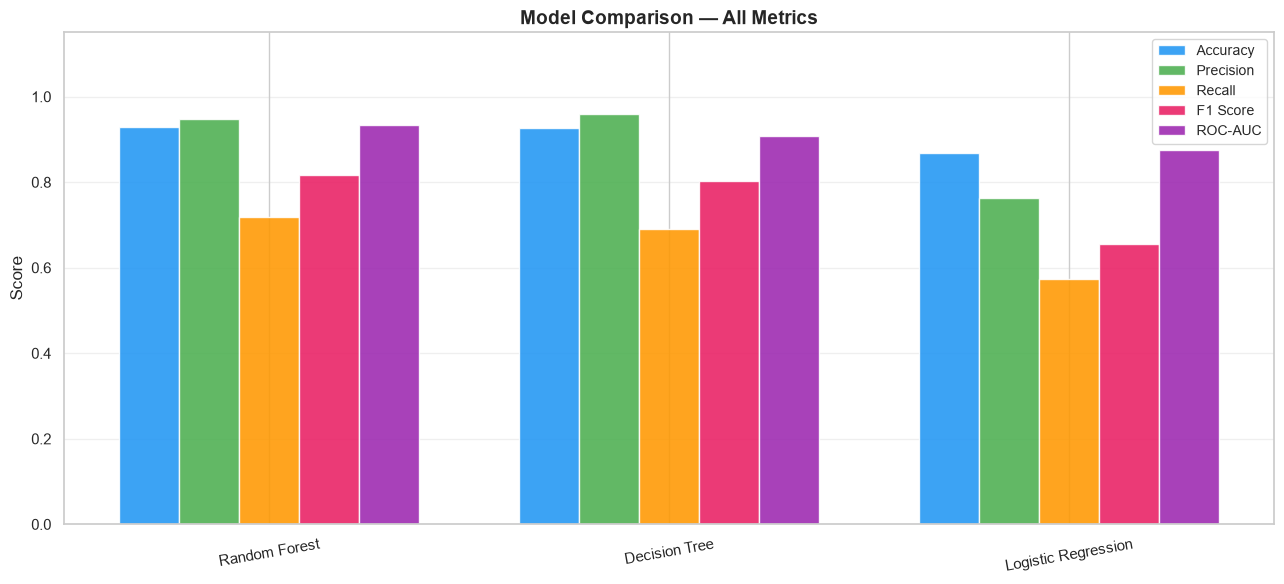

Saved: model_comparison.png


In [52]:
##model comparison
# ============================================
# Model Comparison — All Metrics
# ============================================

metrics_to_plot = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'ROC-AUC'
]

x = np.arange(len(summary_df))
width = 0.15

palette = [
    '#2196F3',
    '#4CAF50',
    '#FF9800',
    '#E91E63',
    '#9C27B0'
]

fig, ax = plt.subplots(figsize=(13, 6))

for i, metric in enumerate(metrics_to_plot):

    if metric in summary_df.columns:
        ax.bar(
            x + i * width,
            summary_df[metric],
            width,
            label=metric,
            color=palette[i],
            alpha=0.88
        )

ax.set_xticks(x + width * 2)

ax.set_xticklabels(
    summary_df['Model'],
    fontsize=11,
    rotation=10
)

ax.set_ylim(0, 1.15)

ax.set_ylabel(
    'Score',
    fontsize=12
)

ax.set_title(
    'Model Comparison — All Metrics',
    fontsize=14,
    fontweight='bold'
)

ax.legend(
    loc='upper right',
    fontsize=10
)

ax.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

# Save locally
plt.savefig(
    'model_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Saved: model_comparison.png')

In [53]:
# ============================================
# Save Best Model and Evaluation Summary
# ============================================

# Find models that have CV AUC
valid_results = [
    r for r in results
    if 'cv_auc' in r
]

# Find the model with the highest CV AUC
best = max(
    valid_results,
    key=lambda r: r['cv_auc']
)

# Create model bundle
bundle = {
    'model_name': best['name'],
    'estimator': best['estimator'],
    'scaler': scaler,
    'feature_names': feature_names,
    'cv_auc': best['cv_auc'],
    'best_params': best['best_params']
}

# Save best model locally
joblib.dump(
    bundle,
    'best_model.pkl'
)

# Save evaluation summary locally
summary_df.to_csv(
    'model_evaluation_summary.csv',
    index=False
)

# Print results
print('Best model saved → best_model.pkl')
print('Summary saved    → model_evaluation_summary.csv')

print(f'\nBest Model: {best["name"]}')
print(f'CV AUC:     {best["cv_auc"]:.4f}')
print(f'Parameters: {best["best_params"]}')

Best model saved → best_model.pkl
Summary saved    → model_evaluation_summary.csv

Best Model: Random Forest
CV AUC:     0.9317
Parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}


In [54]:
# ============================================
# Predict Credit Risk for a New Applicant
# ============================================

def predict_applicant(
    person_income,
    loan_amnt,
    person_emp_length,
    loan_int_rate,
    loan_percent_income,
    person_age=35,
    person_home_ownership='RENT',
    loan_intent='PERSONAL',
    loan_grade='B',
    cb_person_default_on_file='N',
    cb_person_cred_hist_length=5
):
    """
    Predict creditworthiness for a single new applicant.
    """

    # --------------------------------------------
    # 1. Create applicant DataFrame
    # --------------------------------------------

    row = {
        'person_age': person_age,
        'person_income': person_income,
        'person_home_ownership': person_home_ownership,
        'person_emp_length': person_emp_length,
        'loan_intent': loan_intent,
        'loan_grade': loan_grade,
        'loan_amnt': loan_amnt,
        'loan_int_rate': loan_int_rate,
        'loan_percent_income': loan_percent_income,
        'cb_person_default_on_file': cb_person_default_on_file,
        'cb_person_cred_hist_length': cb_person_cred_hist_length
    }

    df_row = pd.DataFrame([row])


    # --------------------------------------------
    # 2. Feature Engineering
    # --------------------------------------------

    df_row['loan_to_income'] = (
        df_row['loan_amnt'] /
        (df_row['person_income'] + 1)
    )

    df_row['high_interest_flag'] = (
        df_row['loan_int_rate'] >
        df['loan_int_rate'].quantile(0.75)
    ).astype(int)

    df_row['low_income_flag'] = (
        df_row['person_income'] <
        df['person_income'].quantile(0.25)
    ).astype(int)

    df_row['high_loan_pct_flag'] = (
        df_row['loan_percent_income'] > 0.4
    ).astype(int)

    df_row['emp_exp_bucket'] = pd.cut(
        df_row['person_emp_length'],
        bins=[-1, 2, 5, 10, 100],
        labels=['junior', 'mid', 'senior', 'veteran']
    ).astype(str)

    df_row['income_bracket'] = pd.cut(
        df_row['person_income'],
        bins=[0, 30000, 60000, 100000, 1e9],
        labels=['low', 'medium', 'high', 'very_high']
    ).astype(str)


    # --------------------------------------------
    # 3. One-Hot Encoding
    # --------------------------------------------

    df_row = pd.get_dummies(
        df_row,
        columns=ohe_cols,
        drop_first=True
    )

    bool_cols = df_row.select_dtypes(
        include='bool'
    ).columns

    df_row[bool_cols] = df_row[bool_cols].astype(int)

    df_row.columns = df_row.columns.astype(str)


    # --------------------------------------------
    # 4. Match Training Features
    # --------------------------------------------

    for col in feature_names:

        if col not in df_row.columns:
            df_row[col] = 0

    df_row = df_row[feature_names]


    # --------------------------------------------
    # 5. Scale Numeric Variables
    # --------------------------------------------

    df_row[num_scale_cols] = scaler.transform(
        df_row[num_scale_cols]
    )


    # --------------------------------------------
    # 6. Make Prediction
    # --------------------------------------------

    label = best['estimator'].predict(df_row)[0]

    prob = best['estimator'].predict_proba(
        df_row
    )[0][1]


    # --------------------------------------------
    # 7. Interpret Prediction
    # --------------------------------------------

    if label == 1:
        verdict = 'DEFAULT RISK — Not Creditworthy'
    else:
        verdict = 'CREDITWORTHY — Low Risk'


    if abs(prob - 0.5) > 0.3:
        confidence = 'HIGH'
    elif abs(prob - 0.5) > 0.15:
        confidence = 'MEDIUM'
    else:
        confidence = 'LOW'


    # --------------------------------------------
    # 8. Display Results
    # --------------------------------------------

    print('\n── Applicant Profile ──────────────────────────────')

    print(
        f'  Income: ${person_income:,.0f} | '
        f'Loan: ${loan_amnt:,.0f} | '
        f'Rate: {loan_int_rate}%'
    )

    print(
        f'  Loan % of Income: {loan_percent_income:.0%} | '
        f'Emp: {person_emp_length} yrs'
    )

    print('── Prediction ─────────────────────────────────────')

    print(f'  {verdict}')

    print(
        f'  Default Probability : {prob:.2%}'
    )

    print(
        f'  Confidence          : {confidence}'
    )

    return {
        'label': int(label),
        'default_probability': round(float(prob), 4)
    }


# ============================================
# Test Cases
# ============================================

print('=' * 52)

print(
    'TEST 1: Good applicant '
    '(high income, low debt)'
)

predict_applicant(
    person_income=85000,
    loan_amnt=10000,
    person_emp_length=8,
    loan_int_rate=9.5,
    loan_percent_income=0.12,
    loan_grade='A'
)


print('\n' + '=' * 52)

print(
    'TEST 2: Risky applicant '
    '(low income, high debt)'
)

predict_applicant(
    person_income=22000,
    loan_amnt=20000,
    person_emp_length=0,
    loan_int_rate=23.0,
    loan_percent_income=0.91,
    loan_grade='E'
)

TEST 1: Good applicant (high income, low debt)

── Applicant Profile ──────────────────────────────
  Income: $85,000 | Loan: $10,000 | Rate: 9.5%
  Loan % of Income: 12% | Emp: 8 yrs
── Prediction ─────────────────────────────────────
  CREDITWORTHY — Low Risk
  Default Probability : 1.00%
  Confidence          : HIGH

TEST 2: Risky applicant (low income, high debt)

── Applicant Profile ──────────────────────────────
  Income: $22,000 | Loan: $20,000 | Rate: 23.0%
  Loan % of Income: 91% | Emp: 0 yrs
── Prediction ─────────────────────────────────────
  DEFAULT RISK — Not Creditworthy
  Default Probability : 61.50%
  Confidence          : LOW


{'label': 1, 'default_probability': 0.615}